<a href="https://colab.research.google.com/github/KatarinaNunes/Atividade_Disciplina/blob/main/M_LEPRAE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
!ls /content/drive/MyDrive


 0806-rm-197.en.pt.pdf
 0b36e19f3c2371d646a473c5d42cdcaf.pdf
 1261.full.en.pt.pdf
 15._Influ_ncia_do_sequenciamento_de_nova_gera_o_no_futuro_da_gen_tica_da_conserva_o.pdf
 1Rgk7DDd3e9w1XNNkE9J_019.613.722-58.pdf
 1-s2.0-S0042682207003236-main.en.pt.pdf
 1-s2.0-S221466361500005X-main.pdf
 20211013_174158.jpg
 20240328_153856.jpg
 20240904_093845.jpg
 20240904_093857.jpg
'2024-11-02 22-22-23.mkv'
'2024-11-02 22-34-21.mkv'
'2025-01-10 23-15-21.mkv'
'2025-08-02 20-57-46.mkv'
'2025-08-02 21-23-50.mkv'
 47847793.gdoc
 8cdf3c4f63ceb7bca070c065cf2a35fa.pdf
 9964e3ee28118469406c081b0e7ce968_jqhd3o8jmk44rmlflooegifo40_c_70_receitas_de_sabonetes.pdf
 a64b6d2c29017322948c7e1b240d8481_f9qet6da6s6hh6egoegaaaq9i5_c_lista_de_fornecedores.pdf
'ABSTRACT - XMEETING_rev.docx'
 ALL.chr22.phase3_shapeit2_mvncall_integrated_v5b.20130502.genotypes.vcf.gz
'Amostras Indígena Pará.gdoc'
 anotacao_prokka
 Apostila-cosmética-natural.pdf
 artigo
'artigos principais tcc'
 backup
'bes-nfev-qov (2021-04-23 at 11:37

In [5]:
!ls /content/drive/MyDrive/variants_mlep


pandadock_all_variants.csv	 pandadock_report_S456L.gsheet
pandadock_report_AC1082S.gsheet  pandadock_report_S456M.gsheet
pandadock_report_G448D.gsheet	 pandadock_report_T171N.gsheet
pandadock_report_H451Y.gsheet	 pandadock_report_T433I.gsheet
pandadock_report_N1111D.gsheet	 pandadock_report_WT.gsheet


In [6]:
!pip install --quiet gspread gspread_dataframe


In [7]:
from google.colab import auth
auth.authenticate_user()

import google.auth
creds, _ = google.auth.default()

from googleapiclient.discovery import build
drive_service = build("drive", "v3", credentials=creds)

!pip -q install gspread gspread_dataframe
import gspread
from gspread_dataframe import get_as_dataframe
gc = gspread.authorize(creds)


In [8]:
FOLDER_NAME = "variants_mlep"

q = (
    f"name='{FOLDER_NAME}' and "
    "mimeType='application/vnd.google-apps.folder' and "
    "'root' in parents and trashed=false"
)

res = drive_service.files().list(q=q, fields="files(id,name)").execute()
folders = res.get("files", [])

if not folders:
    raise RuntimeError("Não achei a pasta 'variants_mlep' no root do Meu Drive. Renomeou/moveu?")
folder_id = folders[0]["id"]
print("Folder ID:", folder_id)


Folder ID: 1cXs9ji1JsCQgSKSqS9uK4MIFsxQF0XTx


In [9]:
import pandas as pd

# Usa o folder_id que você já obteve:
folder_id = "1cXs9ji1JsCQgSKSqS9uK4MIFsxQF0XTx"

q = (
    f"'{folder_id}' in parents and "
    "mimeType='application/vnd.google-apps.spreadsheet' and "
    "name contains 'pandadock_report_' and trashed=false"
)

res = drive_service.files().list(q=q, fields="files(id,name)").execute()
sheets = res.get("files", [])

print("Planilhas encontradas:", len(sheets))
print(*[s["name"] for s in sheets], sep="\n")

all_dfs = []
errors = []

for s in sheets:
    name = s["name"]
    sid  = s["id"]
    variant = name.replace("pandadock_report_", "").strip()

    try:
        sh = gc.open_by_key(sid)
        ws = sh.sheet1  # primeira aba

        df = get_as_dataframe(ws, evaluate_formulas=True)
        df = df.dropna(how="all").dropna(axis=1, how="all")

        df["Variant"] = variant
        all_dfs.append(df)

    except Exception as e:
        errors.append((name, str(e)))

df_all = pd.concat(all_dfs, ignore_index=True) if all_dfs else pd.DataFrame()

print("\nDFs lidos:", len(all_dfs))
print("Erros:", len(errors))
if errors:
    print("\nPrimeiros erros:")
    for it in errors[:5]:
        print(it)

df_all.head()


Planilhas encontradas: 9
pandadock_report_AC1082S
pandadock_report_G448D
pandadock_report_H451Y
pandadock_report_N1111D
pandadock_report_S456L
pandadock_report_S456M
pandadock_report_T171N
pandadock_report_T433I
pandadock_report_WT

DFs lidos: 9
Erros: 0


,Rank,Pose_ID,Score,Energy,Binding_Affinity,IC50_uM,EC50_uM,Ligand_Efficiency,VdW_Energy,Electrostatic_Energy,HBond_Energy,Hydrophobic_Energy,Solvation_Energy,Entropy_Energy,Clash_Score,HBond_Count,Hydrophobic_Count,Salt_Bridge_Count,Variant
0,1.0,pose_1,12.348674,-12.348674,-7.409204,3.70,37.0,-0.063327,0.074944,0.0,-6.0,-4.0,0.0,0.0,122.688277,0.0,0.0,0.0,AC1082S
1,2.0,pose_2,12.506461,-12.506461,-7.503877,3.16,31.6,-0.064136,0.075629,0.0,-6.0,-4.0,0.0,0.0,119.227255,0.0,0.0,0.0,AC1082S
2,3.0,pose_3,12.768492,-12.768492,-7.661095,2.42,24.2,-0.065479,0.075192,0.0,-6.0,-4.0,0.0,0.0,123.230790,0.0,0.0,0.0,AC1082S
3,4.0,pose_4,12.816959,-12.816959,-7.690175,2.30,23.0,-0.065728,0.074907,0.0,-6.0,-4.0,0.0,0.0,121.806830,0.0,0.0,0.0,AC1082S
4,5.0,pose_5,12.847558,-12.847558,-7.708535,2.23,22.3,-0.065885,0.075779,0.0,-6.0,-4.0,0.0,0.0,124.020830,0.0,0.0,0.0,AC1082S


In [10]:
df_all.to_csv("/content/drive/MyDrive/variants_mlep/pandadock_all_variants.csv", index=False)
print("OK: salvo no Drive em variants_mlep/pandadock_all_variants.csv")


OK: salvo no Drive em variants_mlep/pandadock_all_variants.csv


In [11]:
import pandas as pd
import re

in_path  = "/content/drive/MyDrive/variants_mlep/pandadock_all_variants.csv"
df = pd.read_csv(in_path)

# --- 1) Normaliza o nome da variante (Variant) ---
# Ex.: "S456M" -> "Ser456Met" (opcional) ou mantém "S456M" padronizado
aa1_to_aa3 = {
    "A":"Ala","R":"Arg","N":"Asn","D":"Asp","C":"Cys","Q":"Gln","E":"Glu","G":"Gly",
    "H":"His","I":"Ile","L":"Leu","K":"Lys","M":"Met","F":"Phe","P":"Pro","S":"Ser",
    "T":"Thr","W":"Trp","Y":"Tyr","V":"Val"
}

def clean_variant(v):
    if pd.isna(v):
        return None
    v = str(v).strip()

    # casos tipo WT, wt, WildType etc.
    if v.upper() in {"WT", "WILD", "WILDTYPE", "WILD_TYPE"}:
        return "WT"

    # remove espaços e caracteres estranhos
    v = re.sub(r"\s+", "", v)

    # padrão: S456M / T171N / N1111D etc
    m = re.match(r"^([A-Z])(\d+)([A-Z])$", v.upper())
    if m:
        ref, pos, alt = m.group(1), m.group(2), m.group(3)
        return f"{ref}{pos}{alt}"  # versão curta padronizada

    # se vier tipo "Ser456Met"
    m3 = re.match(r"^([A-Za-z]{3})(\d+)([A-Za-z]{3})$", v)
    if m3:
        ref3, pos, alt3 = m3.group(1).title(), m3.group(2), m3.group(3).title()
        # converte 3 letras -> 1 letra se possível
        aa3_to_aa1 = {v:k for k,v in aa1_to_aa3.items()}
        ref1 = aa3_to_aa1.get(ref3, "?")
        alt1 = aa3_to_aa1.get(alt3, "?")
        if ref1 != "?" and alt1 != "?":
            return f"{ref1}{pos}{alt1}"
        return f"{ref3}{pos}{alt3}"

    # fallback: devolve limpo
    return v

df["Variant_clean"] = df["Variant"].apply(clean_variant)

# (opcional) criar versão longa "Ser456Met" para figurinhas/relatório
def variant_to_long(v):
    if v == "WT" or pd.isna(v):
        return v
    m = re.match(r"^([A-Z])(\d+)([A-Z])$", str(v))
    if not m:
        return v
    ref, pos, alt = m.group(1), m.group(2), m.group(3)
    return f"{aa1_to_aa3.get(ref, ref)}{pos}{aa1_to_aa3.get(alt, alt)}"

df["Variant_long"] = df["Variant_clean"].apply(variant_to_long)

df[["Variant","Variant_clean","Variant_long"]].drop_duplicates().sort_values("Variant_clean").head(20)


,Variant,Variant_clean,Variant_long
0,AC1082S,AC1082S,AC1082S
50,G448D,G448D,Gly448Asp
100,H451Y,H451Y,His451Tyr
150,N1111D,N1111D,Asn1111Asp
200,S456L,S456L,Ser456Leu
250,S456M,S456M,Ser456Met
300,T171N,T171N,Thr171Asn
350,T433I,T433I,Thr433Ile
400,WT,WT,WT


In [12]:
cols = list(df.columns)

# tenta achar colunas numéricas relevantes
numeric_cols = df.select_dtypes(include="number").columns.tolist()

print("Numéricas:", numeric_cols)

# candidatos típicos: score, affinity, energy, deltaG, ic50, kd...
candidates = [c for c in cols if re.search(r"(score|affin|energy|dg|delta|ic50|kd|kcal)", c, re.IGNORECASE)]
print("Candidatas:", candidates)


Numéricas: ['Rank', 'Score', 'Energy', 'Binding_Affinity', 'IC50_uM', 'EC50_uM', 'Ligand_Efficiency', 'VdW_Energy', 'Electrostatic_Energy', 'HBond_Energy', 'Hydrophobic_Energy', 'Solvation_Energy', 'Entropy_Energy', 'Clash_Score', 'HBond_Count', 'Hydrophobic_Count', 'Salt_Bridge_Count']
Candidatas: ['Score', 'Energy', 'Binding_Affinity', 'IC50_uM', 'VdW_Energy', 'Electrostatic_Energy', 'HBond_Energy', 'Hydrophobic_Energy', 'Solvation_Energy', 'Entropy_Energy', 'Clash_Score', 'Salt_Bridge_Count']


In [13]:
PRIMARY = "Binding_Affinity"   # ranking principal
SECONDARY = "IC50_uM"          # interpretação biológica


In [14]:
df_best = (
    df.sort_values(
        ["Variant_clean", PRIMARY],
        ascending=[True, True]   # mais negativo = melhor
    )
    .groupby("Variant_clean", as_index=False)
    .head(1)
)

df_best = df_best.sort_values(PRIMARY)

df_best[["Variant_clean","Variant_long",PRIMARY,"IC50_uM"]].head(10)


,Variant_clean,Variant_long,Binding_Affinity,IC50_uM
449,WT,WT,-8.317607,0.799
249,S456L,Ser456Leu,-8.310785,0.808
199,N1111D,Asn1111Asp,-8.306393,0.814
349,T171N,Thr171Asn,-8.294520,0.831
299,S456M,Ser456Met,-8.294311,0.831
399,T433I,Thr433Ile,-8.280019,0.851
49,AC1082S,AC1082S,-8.271972,0.863
149,H451Y,His451Tyr,-8.266172,0.871
99,G448D,Gly448Asp,-8.237949,0.914


#PLOTS PCA -> PADROES ESTRUTURAIS

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

features = [
    "VdW_Energy", "Electrostatic_Energy", "HBond_Energy",
    "Hydrophobic_Energy", "Solvation_Energy", "Entropy_Energy",
    "Clash_Score"
]

X = df_best[features].fillna(0)

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
PCs = pca.fit_transform(X_scaled)

df_pca = df_best.copy()
df_pca["PC1"] = PCs[:,0]
df_pca["PC2"] = PCs[:,1]

print("Explained variance:", pca.explained_variance_ratio_)
df_pca[["Variant_clean","PC1","PC2"]].head()


Explained variance: [0.73453108 0.26546892]


,Variant_clean,PC1,PC2
449,WT,0.545948,1.068378
249,S456L,-1.012903,0.845716
199,N1111D,1.101655,0.509959
349,T171N,0.508811,-0.460877
299,S456M,0.613311,-0.798391


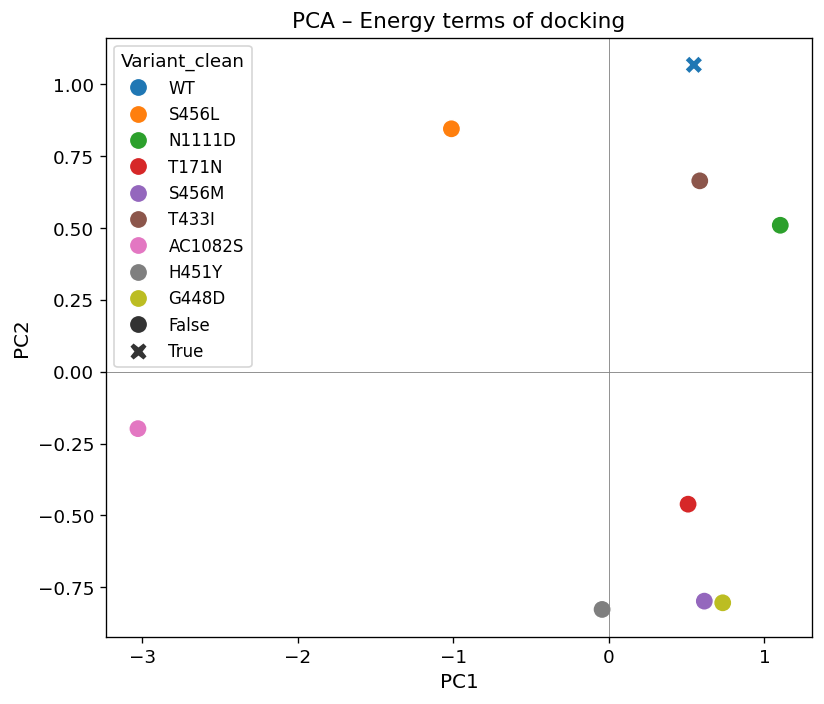

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))
sns.scatterplot(
    data=df_pca,
    x="PC1", y="PC2",
    hue="Variant_clean",
    style=(df_pca["Variant_clean"]=="WT"),
    s=120
)
plt.title("PCA – Energy terms of docking")
plt.axhline(0,color="gray",lw=0.5)
plt.axvline(0,color="gray",lw=0.5)
plt.tight_layout()
plt.show()


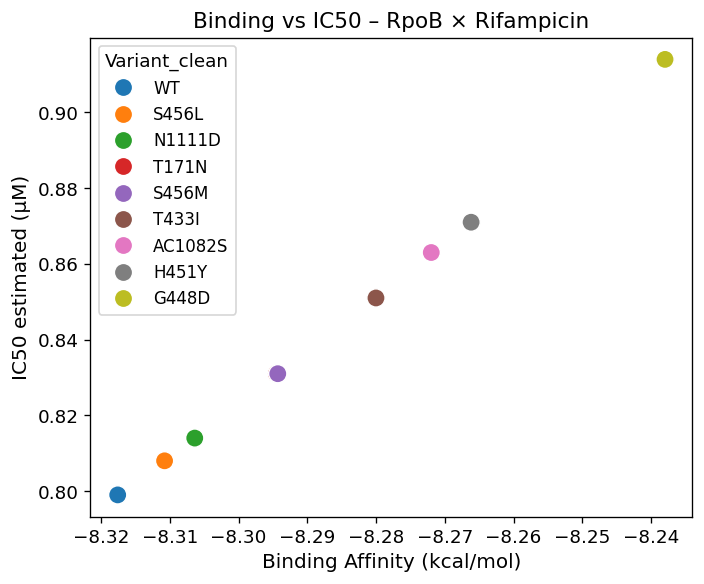

In [17]:
plt.figure(figsize=(6,5))
sns.scatterplot(
    data=df_best,
    x=PRIMARY,
    y="IC50_uM",
    hue="Variant_clean",
    s=120
)

plt.xlabel("Binding Affinity (kcal/mol)")
plt.ylabel("IC50 estimated (µM)")
plt.title("Binding vs IC50 – RpoB × Rifampicin")
plt.tight_layout()
plt.show()


In [18]:
from scipy.stats import spearmanr

rho, p = spearmanr(df_best[PRIMARY], df_best["IC50_uM"])
print(f"Spearman ρ = {rho:.3f} | p = {p:.2e}")


Spearman ρ = 0.996 | p = 1.54e-08


In [19]:
df_best["RAM_like"] = df_best["IC50_uM"] > 1.0  # exemplo


In [20]:
globals().keys()


dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', '_', '__', '___', '_i', '_ii', '_iii', '_i1', 'np', 'plt', 'Line2D', 'xcol', 'ycol', 'label_col', 'class_col', 'fig', 'ax', 'levels', '_i2', '_i3', 'drive', '_i4', '_exit_code', '_i5', '_i6', '_i7', 'auth', 'google', 'creds', 'build', 'drive_service', 'gspread', 'get_as_dataframe', 'gc', '_i8', 'FOLDER_NAME', 'q', 'res', 'folders', 'folder_id', '_i9', 'pd', 'sheets', 'all_dfs', 'errors', 's', 'name', 'sid', 'variant', 'sh', 'ws', 'df', 'df_all', '_9', '_i10', '_i11', 're', 'in_path', 'aa1_to_aa3', 'clean_variant', 'variant_to_long', '_11', '_i12', 'cols', 'numeric_cols', 'candidates', '_i13', 'PRIMARY', 'SECONDARY', '_i14', 'df_best', '_14', '_i15', 'StandardScaler', 'PCA', 'features', 'X', 'X_scaled', 'pca', 'PCs', 'df_pca', '_15', '_i16', 'sns', '_i17', '_i18', 'spearmanr', 'rho', 'p', '_i19', '_i20'])

In [21]:
df_final = df_all.copy()


In [22]:
df_final.columns


Index(['Rank', 'Pose_ID', 'Score', 'Energy', 'Binding_Affinity', 'IC50_uM',
       'EC50_uM', 'Ligand_Efficiency', 'VdW_Energy', 'Electrostatic_Energy',
       'HBond_Energy', 'Hydrophobic_Energy', 'Solvation_Energy',
       'Entropy_Energy', 'Clash_Score', 'HBond_Count', 'Hydrophobic_Count',
       'Salt_Bridge_Count', 'Variant'],
      dtype='object')

In [23]:
print(df_final.columns.tolist())


['Rank', 'Pose_ID', 'Score', 'Energy', 'Binding_Affinity', 'IC50_uM', 'EC50_uM', 'Ligand_Efficiency', 'VdW_Energy', 'Electrostatic_Energy', 'HBond_Energy', 'Hydrophobic_Energy', 'Solvation_Energy', 'Entropy_Energy', 'Clash_Score', 'HBond_Count', 'Hydrophobic_Count', 'Salt_Bridge_Count', 'Variant']


In [24]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

df = df_final.copy()

# garante texto e tira espaços
df["Variant"] = df["Variant"].astype(str).str.strip()

# padrão: WT vs mutante
df["Variant_clean"] = df["Variant"].str.upper()
df["is_mutant"] = (df["Variant_clean"] != "WT").astype(int)

df[["Variant", "Variant_clean", "is_mutant"]].head()


,Variant,Variant_clean,is_mutant
0,AC1082S,AC1082S,1
1,AC1082S,AC1082S,1
2,AC1082S,AC1082S,1
3,AC1082S,AC1082S,1
4,AC1082S,AC1082S,1


In [25]:
df = df_best.copy()


In [26]:
df.shape


(9, 22)

In [27]:
features_pca = [
    "Binding_Affinity",
    "VdW_Energy",
    "Electrostatic_Energy",
    "HBond_Energy",
    "Hydrophobic_Energy",
    "Solvation_Energy",
    "Entropy_Energy",
    "Clash_Score"
]


In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df[features_pca]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)

df["PC1"] = pcs[:, 0]
df["PC2"] = pcs[:, 1]


In [29]:
df[["Variant_clean", "PC1", "PC2"]].head()


,Variant_clean,PC1,PC2
449,WT,1.260682,-1.221939
249,S456L,-0.280235,-1.637454
199,N1111D,1.430464,-0.338208
349,T171N,0.489559,0.230898
299,S456M,0.505572,0.455832


In [30]:
df["is_mutant"] = (df["Variant_clean"] != "WT").astype(int)


In [31]:
from sklearn.linear_model import LogisticRegression

X = df[["PC1", "IC50_uM"]]
y = df["is_mutant"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LogisticRegression()
model.fit(X_scaled, y)

coef = pd.DataFrame({
    "Feature": X.columns,
    "Coeficiente": model.coef_[0]
}).sort_values("Coeficiente", ascending=False)

coef


,Feature,Coeficiente
1,IC50_uM,0.661695
0,PC1,-0.481742


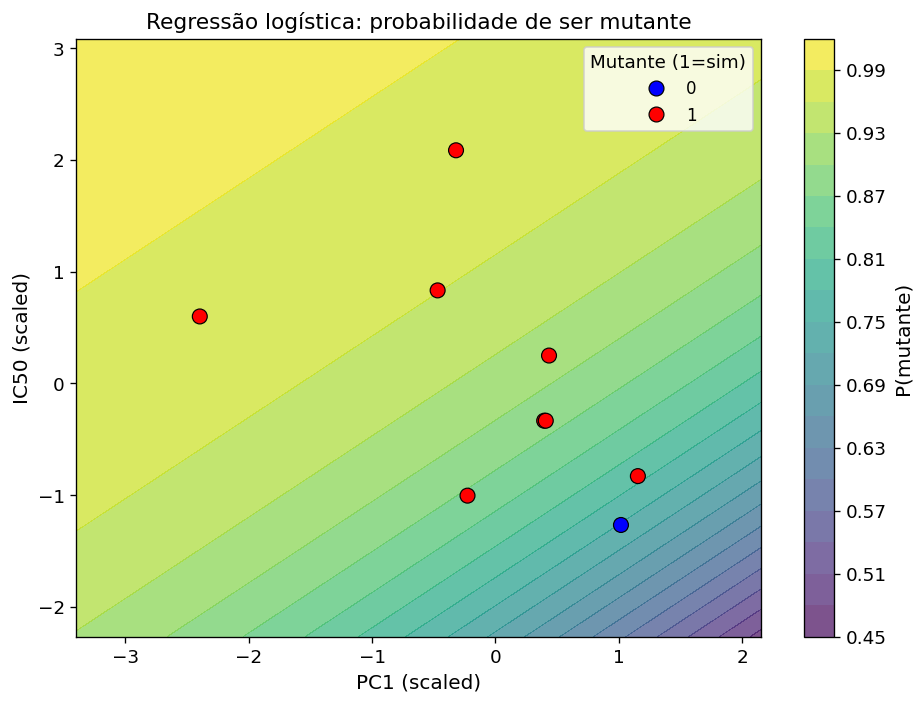

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dados
X = df[["PC1", "IC50_uM"]]
y = df["is_mutant"]

# Padroniza com o MESMO scaler usado no treino
X_scaled = scaler.transform(X)

# Grade para o plano
x_min, x_max = X_scaled[:,0].min() - 1, X_scaled[:,0].max() + 1
y_min, y_max = X_scaled[:,1].min() - 1, X_scaled[:,1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1]
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, levels=20, cmap="viridis", alpha=0.7)

sns.scatterplot(
    x=X_scaled[:,0],
    y=X_scaled[:,1],
    hue=y,
    palette={0:"blue", 1:"red"},
    edgecolor="k",
    s=80
)

plt.xlabel("PC1 (scaled)")
plt.ylabel("IC50 (scaled)")
plt.title("Regressão logística: probabilidade de ser mutante")
plt.legend(title="Mutante (1=sim)")
plt.colorbar(label="P(mutante)")
plt.tight_layout()
plt.show()


In [34]:
df["Variant_clean"].unique()


array(['WT', 'S456L', 'N1111D', 'T171N', 'S456M', 'T433I', 'AC1082S',
       'H451Y', 'G448D'], dtype=object)

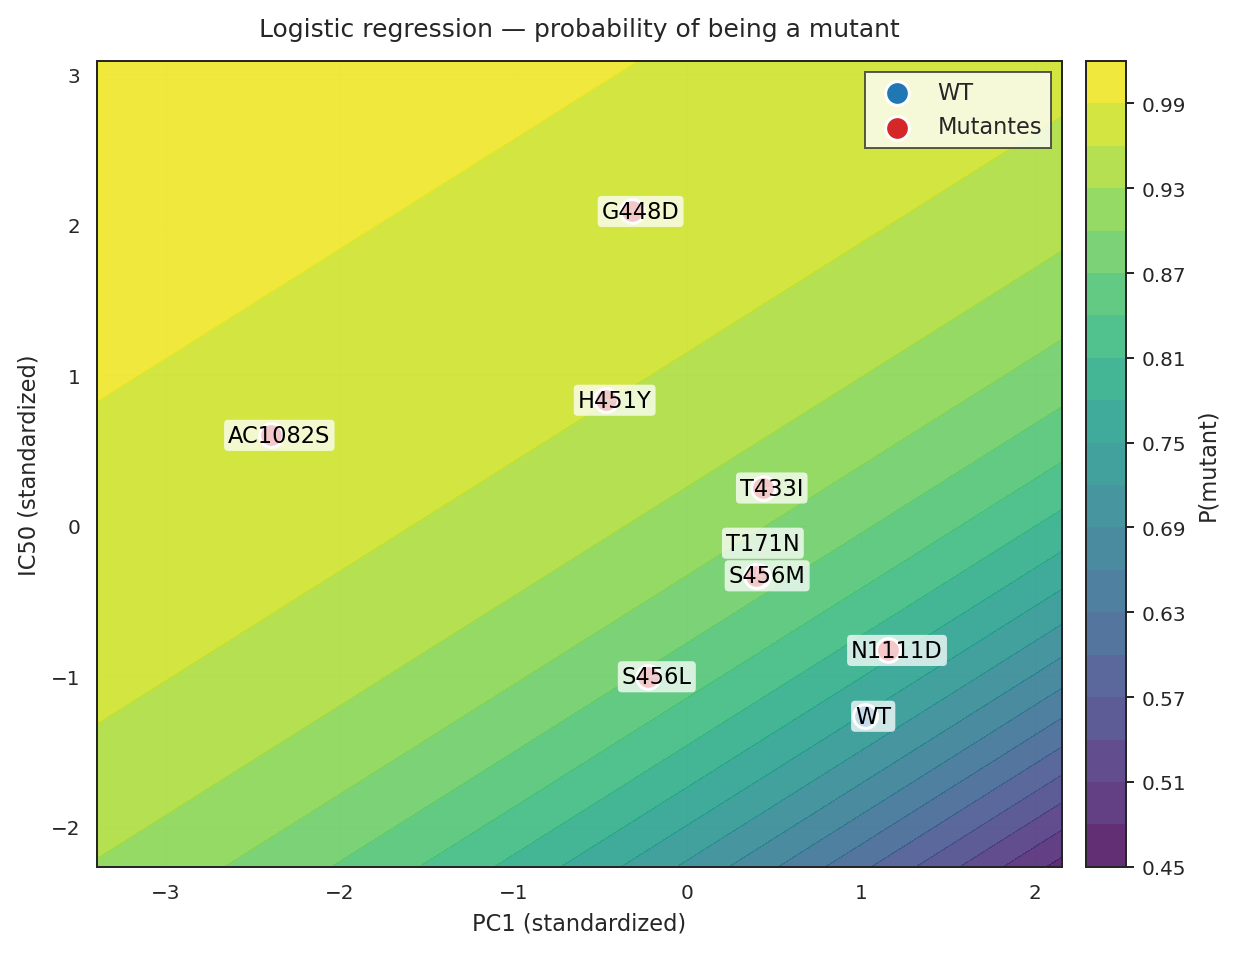

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 0) Checagens rápidas
# =========================
required_cols = ["Variant_clean", "IC50_uM", "PC1", "is_mutant"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Faltam colunas no df: {missing}")

# =========================
# 1) Reduzir para 1 ponto por variante (evita repetição/IndexError)
#    - Aqui escolho o menor IC50 por variante (você pode trocar por melhor Score/Energy)
# =========================
df_plot = (
    df.sort_values(["Variant_clean", "IC50_uM"], ascending=[True, True])
      .groupby("Variant_clean", as_index=False)
      .head(1)
      .reset_index(drop=True)
)

# =========================
# 2) Preparar X e padronizar com o scaler do treino
# =========================
X = df_plot[["PC1", "IC50_uM"]].copy()
y = df_plot["is_mutant"].astype(int).to_numpy()

X_scaled = scaler.transform(X)

# =========================
# 3) Grade para contorno de probabilidade (plano de decisão)
# =========================
x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 350),
    np.linspace(y_min, y_max, 350)
)

Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

# =========================
# 4) Plot (Nature-like)
# =========================
plt.rcParams.update({
    "font.size": 10,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
})

fig, ax = plt.subplots(figsize=(7.2, 5.4), dpi=180)

# Contourf com poucos níveis e alpha suave
cf = ax.contourf(xx, yy, Z, levels=18, cmap="viridis", alpha=0.85)

# Pontos (WT vs Mutante)
# (WT azul, mutantes vermelho; borda branca dá cara de figura de paper)
for cls, color, label in [(0, "#1f77b4", "WT"), (1, "#d62728", "Mutantes")]:
    idx = np.where(y == cls)[0]
    ax.scatter(
        X_scaled[idx, 0], X_scaled[idx, 1],
        s=90, c=color, label=label,
        edgecolors="white", linewidths=1.2, zorder=5
    )

# Eixos e título discreto
ax.set_xlabel("PC1 (standardized)")
ax.set_ylabel("IC50 (standardized)")
ax.set_title("Logistic regression — probability of being a mutant", pad=10)

# Legend bem limpa
leg = ax.legend(frameon=True, fancybox=False, edgecolor="0.2", fontsize=9, loc="upper right")
leg.get_frame().set_linewidth(0.8)

# Colorbar com label simples
cbar = fig.colorbar(cf, ax=ax, pad=0.02)
cbar.set_label("P(mutant)", rotation=90)

# Grid muito sutil (paper vibe)
ax.grid(True, linewidth=0.4, alpha=0.25)

# =========================
# 5) Labels SEM sobrepor (heurística em espiral)
# =========================
fig.canvas.draw()
renderer = fig.canvas.get_renderer()

def bbox_overlap(b1, b2, pad=2):
    # b1, b2 são BBox em pixels
    b1e = b1.from_extents(b1.x0-pad, b1.y0-pad, b1.x1+pad, b1.y1+pad)
    b2e = b2.from_extents(b2.x0-pad, b2.y0-pad, b2.x1+pad, b2.y1+pad)
    return b1e.overlaps(b2e)

# offsets candidatos (em unidades do eixo)
candidates = []
radii = [0.05, 0.08, 0.11, 0.14, 0.18, 0.22, 0.26]
angles = np.linspace(0, 2*np.pi, 18, endpoint=False)
for r in radii:
    for a in angles:
        candidates.append((r*np.cos(a), r*np.sin(a)))

placed_bboxes = []

for j, row in df_plot.iterrows():
    x_pt = X_scaled[j, 0]
    y_pt = X_scaled[j, 1]
    label = row["Variant_clean"]

    placed = False

    for dx, dy in candidates:
        t = ax.text(
            x_pt + dx, y_pt + dy, label,
            fontsize=9,
            ha="center", va="center",
            color="black",
            zorder=7,
            bbox=dict(
                boxstyle="round,pad=0.18",
                facecolor="white",
                edgecolor="none",
                alpha=0.75
            )
        )

        fig.canvas.draw()
        bb = t.get_window_extent(renderer=renderer)

        if any(bbox_overlap(bb, prev) for prev in placed_bboxes):
            t.remove()
            continue

        # aceita
        placed_bboxes.append(bb)
        # linha conectora sutil
        ax.plot([x_pt, x_pt + dx], [y_pt, y_pt + dy], linewidth=0.6, alpha=0.6, zorder=6)
        placed = True
        break

    # fallback: se não couber, coloca acima com linha
    if not placed:
        t = ax.text(
            x_pt, y_pt + 0.30, label,
            fontsize=9, ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.18", facecolor="white", edgecolor="none", alpha=0.75),
            zorder=7
        )
        fig.canvas.draw()
        placed_bboxes.append(t.get_window_extent(renderer=renderer))
        ax.plot([x_pt, x_pt], [y_pt, y_pt + 0.30], linewidth=0.6, alpha=0.6, zorder=6)

plt.tight_layout()
plt.show()


In [45]:
from matplotlib.colors import LinearSegmentedColormap

light_gray_cmap = LinearSegmentedColormap.from_list(
    "light_gray",
    ["#f7f7f7", "#e1e1e1", "#cfcfcf", "#b5b5b5"]
)


In [50]:
!pip install adjustText


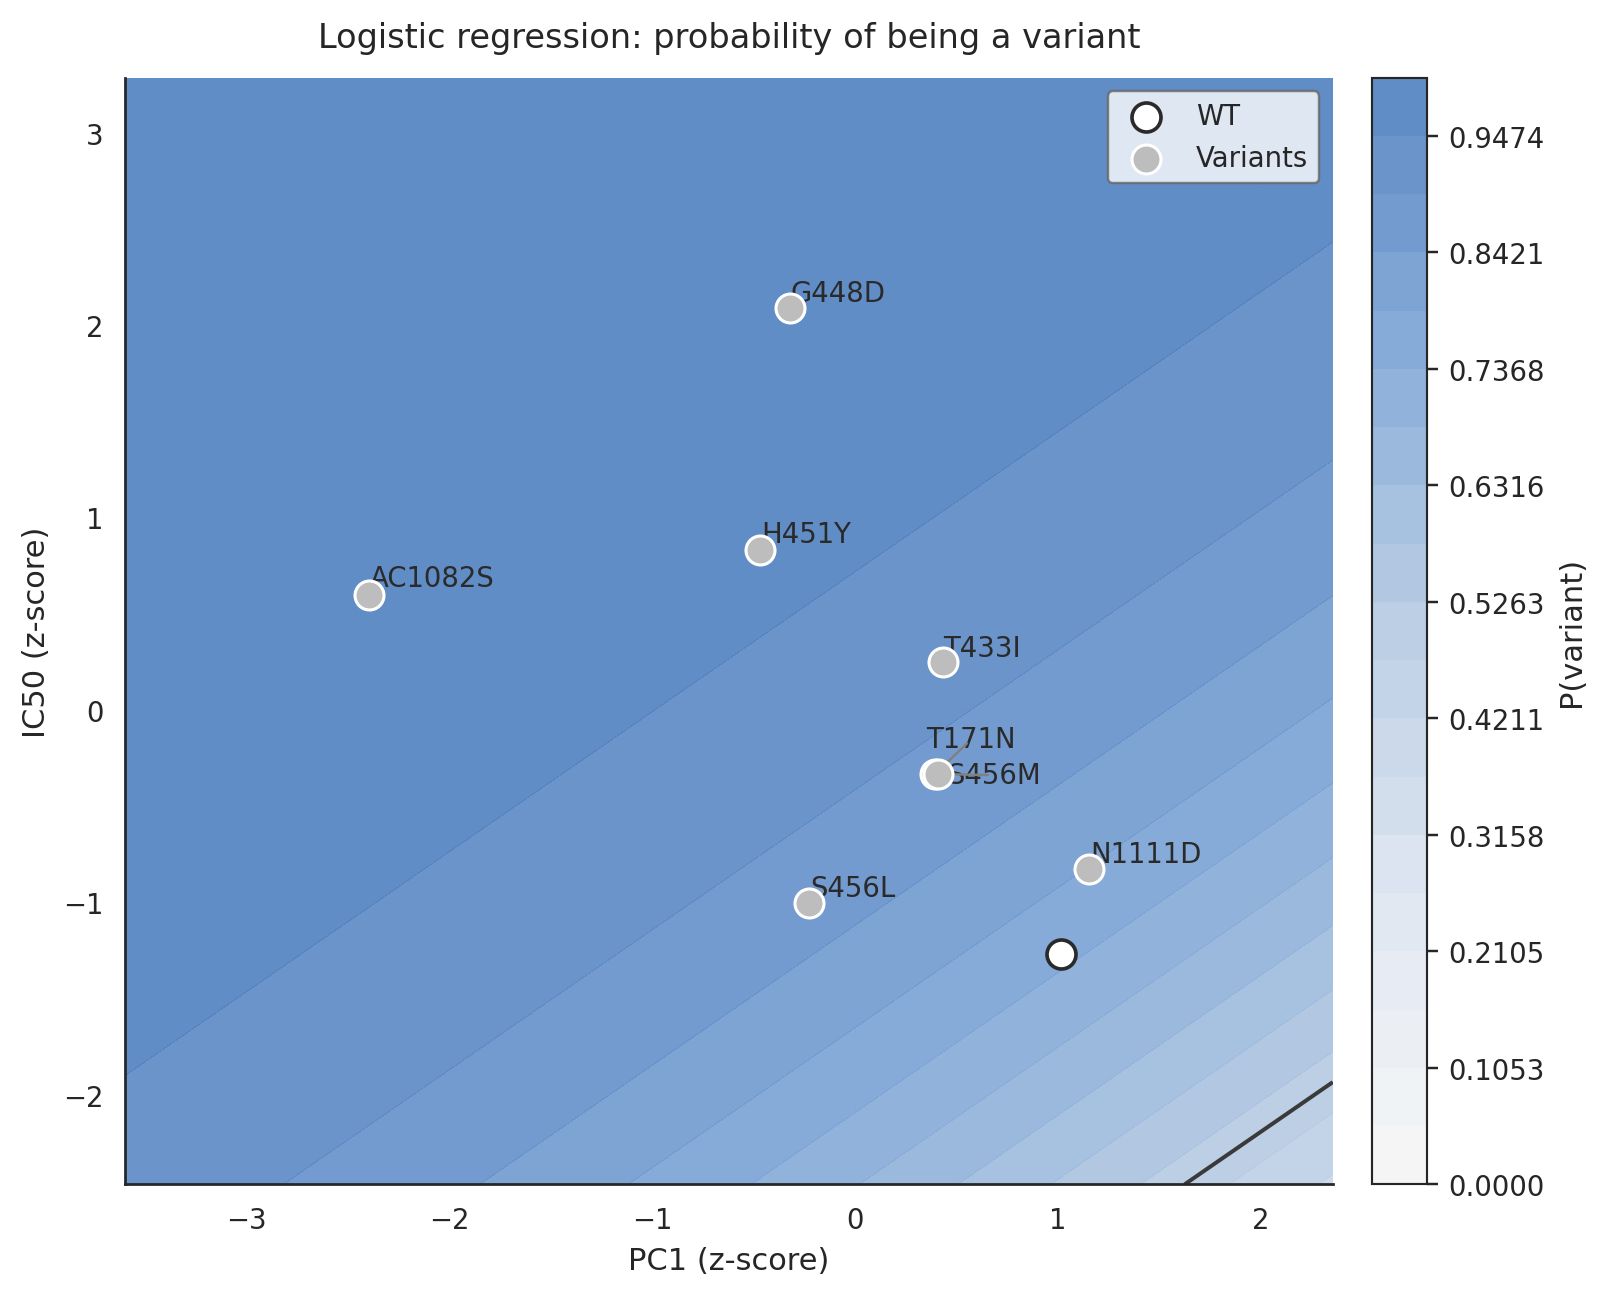

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from adjustText import adjust_text

# =========================
# Colormap (Gray → Blue)
# =========================
gray_blue = LinearSegmentedColormap.from_list(
    "gray_blue",
    ["#f7f7f7", "#dee6f1", "#b7cbe3", "#7fa6d6", "#4f7fbf"]
)

# =========================
# Data
# =========================
X = df[["PC1", "IC50_uM"]].copy()
y = df["is_mutant"].astype(int).values
labels = df["Variant"].values  # ou Variant_clean

X_scaled = scaler.transform(X)

idx_wt = np.where(y == 0)[0]
idx_mut = np.where(y == 1)[0]

# =========================
# Meshgrid
# =========================
x_min, x_max = X_scaled[:,0].min() - 1.2, X_scaled[:,0].max() + 1.2
y_min, y_max = X_scaled[:,1].min() - 1.2, X_scaled[:,1].max() + 1.2

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 320),
    np.linspace(y_min, y_max, 320)
)

Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1]
Z = Z.reshape(xx.shape)

# =========================
# Plot
# =========================
fig, ax = plt.subplots(figsize=(7.4, 6.0))

levels = np.linspace(0, 1, 20)

cf = ax.contourf(
    xx, yy, Z,
    levels=levels,
    cmap=gray_blue,
    alpha=0.92
)

# Decision boundary
ax.contour(
    xx, yy, Z,
    levels=[0.5],
    colors="#3a3a3a",
    linewidths=1.3
)

# WT
ax.scatter(
    X_scaled[idx_wt,0], X_scaled[idx_wt,1],
    s=90,
    facecolors="white",
    edgecolors="#2a2a2a",
    linewidths=1.2,
    label="WT",
    zorder=5
)

# Variants
ax.scatter(
    X_scaled[idx_mut,0], X_scaled[idx_mut,1],
    s=90,
    facecolors="#bdbdbd",
    edgecolors="white",
    linewidths=1.0,
    label="Variants",
    zorder=5
)

# =========================
# Labels with NO OVERLAP
# =========================
texts = []
for i in idx_mut:  # normalmente rotulamos só mutantes
    texts.append(
        ax.text(
            X_scaled[i,0],
            X_scaled[i,1],
            labels[i],
            fontsize=9,
            color="#2a2a2a"
        )
    )

adjust_text(
    texts,
    ax=ax,
    expand_points=(1.2, 1.4),
    expand_text=(1.2, 1.4),
    arrowprops=dict(
        arrowstyle="-",
        color="0.5",
        lw=0.8
    )
)

# =========================
# Final styling
# =========================
ax.set_xlabel("PC1 (z-score)")
ax.set_ylabel("IC50 (z-score)")
ax.set_title("Logistic regression: probability of being a variant", pad=10)

ax.grid(True, linewidth=0.4, alpha=0.18)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

leg = ax.legend(frameon=True)
leg.get_frame().set_edgecolor("0.4")
leg.get_frame().set_linewidth(0.8)

cbar = fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.03)
cbar.set_label("P(variant)")
cbar.outline.set_linewidth(0.7)

plt.tight_layout()
plt.show()

# Export opcional
# fig.savefig("logreg_variants_labeled.png", dpi=300, bbox_inches="tight")
# fig.savefig("logreg_variants_labeled.pdf", bbox_inches="tight")


ANÁLISE FOLDX